In [1]:
from __future__ import annotations

import math
import os
import sys
import time as t
from datetime import date
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns

sys.path.append("../0-data") 
from archi_dict import archi_sorghum as archi_1
from archi_dict import archi_maize as archi_2

from openalea.archicrop.simulation import compute_extinction_coef, concat_usm

In [2]:
df_stics = pd.read_csv("../../1-simul_stics/2-outputs/simulations_stics_intercrops.csv")
df_stics["usm"] = df_stics["situation"]
df_stics["fapar_stics"] = df_stics["raint"] / (0.48 * 0.95 * df_stics["trg_n"])
df_stics = df_stics[df_stics["raint"] != 0.0]
df_stics = df_stics[df_stics["laimax"] != 0.0]
df_stics = df_stics[df_stics["hauteur"] != 0.0]
df_stics

,situation,Date,pla,somupvtsem,laimax,laisen_n,hauteur,raint,trg_n,ilevs,iamfs,ilaxs,densite,demande,lai_n,Plant,Dominance,algorithm,usm,fapar_stics
208,usm_1,2018-07-06,mai,203.30836,0.00012,0.00000,0.01847,0.00079,21.5,186,218,240,4.16667,0.01000,0.00012,maize,Associated,2.5D,usm_1,0.000081
209,usm_1,2018-07-06,mai,203.30836,0.00012,0.00000,0.01847,0.00079,21.5,186,218,240,4.16667,0.01000,0.00012,maize,Associated,Beer,usm_1,0.000081
212,usm_1,2018-07-07,mai,225.01837,0.00025,0.00000,0.02322,0.00153,18.9,186,218,240,4.16667,0.01000,0.00025,maize,Associated,2.5D,usm_1,0.000178
213,usm_1,2018-07-07,mai,225.01837,0.00025,0.00000,0.02322,0.00153,18.9,186,218,240,4.16667,0.01000,0.00025,maize,Associated,Beer,usm_1,0.000178
214,usm_1,2018-07-07,sor,181.01837,0.00002,0.00000,0.01528,0.00010,18.9,188,232,282,4.16667,0.01000,0.00002,sorghum,Principal,Beer,usm_1,0.000012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41263,usm_9,2018-10-13,sor,1561.63757,4.43769,0.09140,2.49980,7.13167,19.2,188,232,282,11.11111,1.80876,4.38604,sorghum,Principal,Beer,usm_9,0.814564
41264,usm_9,2018-10-14,mai,2216.54102,2.88442,2.93751,2.50000,1.73668,20.7,186,218,240,11.11111,0.69833,0.00000,maize,Associated,2.5D,usm_9,0.183986
41265,usm_9,2018-10-14,mai,2223.13452,2.88022,2.93336,2.50000,1.51072,20.7,186,218,240,11.11111,0.61417,0.00000,maize,Associated,Beer,usm_9,0.160047
41266,usm_9,2018-10-14,sor,1572.56299,4.05810,0.10292,2.49979,7.40045,20.7,188,232,282,11.11111,1.98293,3.99535,sorghum,Principal,2.5D,usm_9,0.784012


In [3]:
from datetime import timedelta, datetime
dates = [] 
current_date = datetime.strptime(min(df_stics["Date"]), "%Y-%m-%d").date()
while current_date <= datetime.strptime(max(df_stics["Date"]), "%Y-%m-%d").date(): 
    dates.append(str(current_date))
    current_date += timedelta(days=1)
steps = {d:s for s,d in enumerate(dates)}

df_stics["step_number"] = df_stics["Date"].map(steps)
df_stics["group"] = df_stics["Plant"]
df_stics["algo"] = df_stics["algorithm"]
df_stics

,situation,Date,pla,somupvtsem,laimax,laisen_n,hauteur,raint,trg_n,ilevs,...,demande,lai_n,Plant,Dominance,algorithm,usm,fapar_stics,step_number,group,algo
208,usm_1,2018-07-06,mai,203.30836,0.00012,0.00000,0.01847,0.00079,21.5,186,...,0.01000,0.00012,maize,Associated,2.5D,usm_1,0.000081,1,maize,2.5D
209,usm_1,2018-07-06,mai,203.30836,0.00012,0.00000,0.01847,0.00079,21.5,186,...,0.01000,0.00012,maize,Associated,Beer,usm_1,0.000081,1,maize,Beer
212,usm_1,2018-07-07,mai,225.01837,0.00025,0.00000,0.02322,0.00153,18.9,186,...,0.01000,0.00025,maize,Associated,2.5D,usm_1,0.000178,2,maize,2.5D
213,usm_1,2018-07-07,mai,225.01837,0.00025,0.00000,0.02322,0.00153,18.9,186,...,0.01000,0.00025,maize,Associated,Beer,usm_1,0.000178,2,maize,Beer
214,usm_1,2018-07-07,sor,181.01837,0.00002,0.00000,0.01528,0.00010,18.9,188,...,0.01000,0.00002,sorghum,Principal,Beer,usm_1,0.000012,2,sorghum,Beer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41263,usm_9,2018-10-13,sor,1561.63757,4.43769,0.09140,2.49980,7.13167,19.2,188,...,1.80876,4.38604,sorghum,Principal,Beer,usm_9,0.814564,100,sorghum,Beer
41264,usm_9,2018-10-14,mai,2216.54102,2.88442,2.93751,2.50000,1.73668,20.7,186,...,0.69833,0.00000,maize,Associated,2.5D,usm_9,0.183986,101,maize,2.5D
41265,usm_9,2018-10-14,mai,2223.13452,2.88022,2.93336,2.50000,1.51072,20.7,186,...,0.61417,0.00000,maize,Associated,Beer,usm_9,0.160047,101,maize,Beer
41266,usm_9,2018-10-14,sor,1572.56299,4.05810,0.10292,2.49979,7.40045,20.7,188,...,1.98293,3.99535,sorghum,Principal,2.5D,usm_9,0.784012,101,sorghum,2.5D


'\ng = sns.relplot(\n    data=fmri,\n    x="timepoint", y="signal",\n    hue="event", style="event", col="region",\n    height=4, aspect=.7, kind="line"\n)\n(g.map(plt.axhline, y=0, color=".7", dashes=(2, 1), zorder=0)\n  .set_axis_labels("Timepoint", "Percent signal change")\n  .set_titles("Region: {col_name} cortex")\n  .tight_layout(w_pad=0))\n'

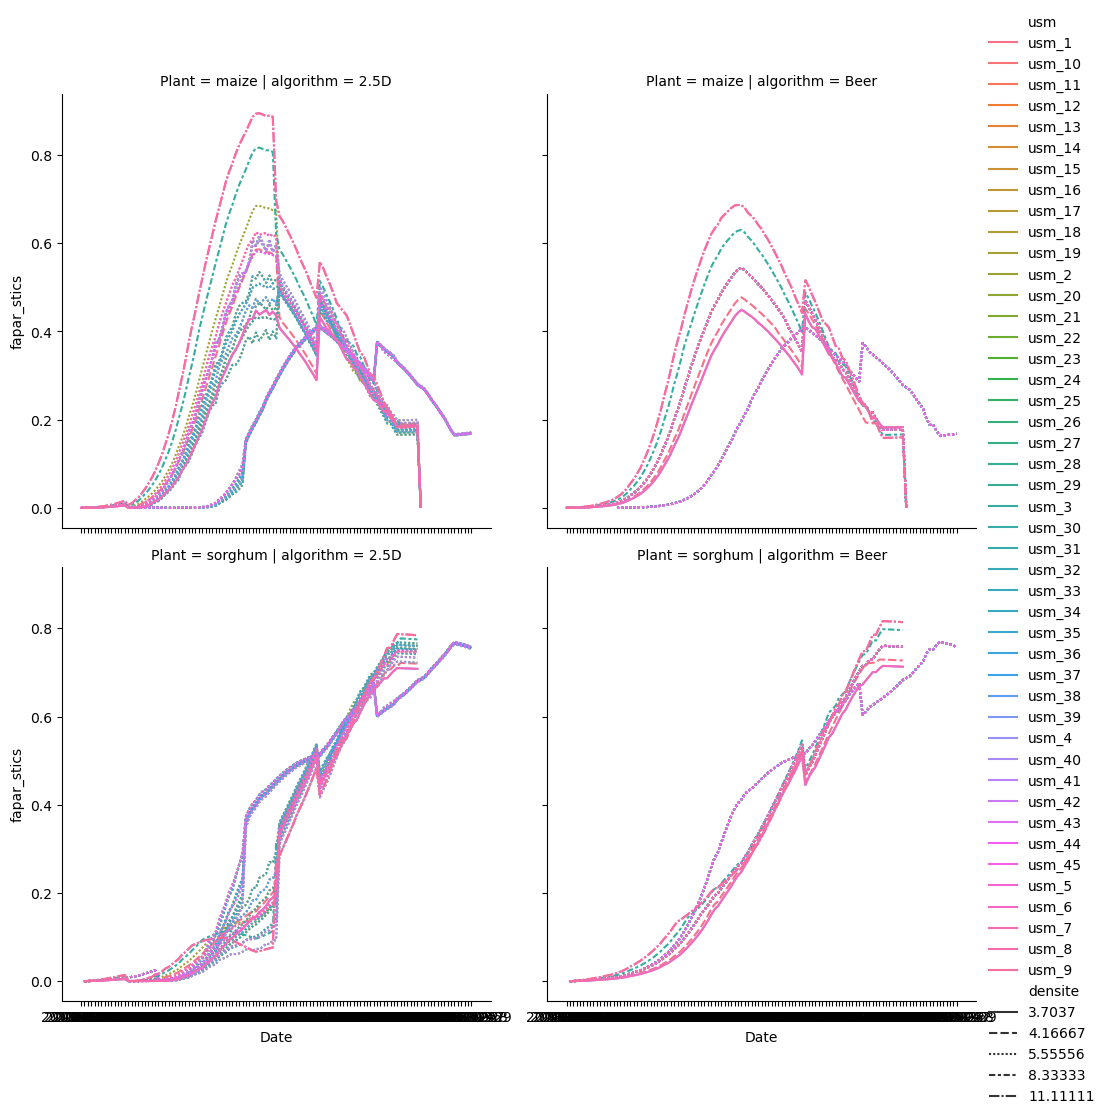

In [4]:
sns.relplot(
    data=df_stics,
    x="Date", 
    y="fapar_stics",
    hue="usm",
    row="Plant",
    col="algorithm",
    style="densite",
    kind="line",
)

'''
g = sns.relplot(
    data=fmri,
    x="timepoint", y="signal",
    hue="event", style="event", col="region",
    height=4, aspect=.7, kind="line"
)
(g.map(plt.axhline, y=0, color=".7", dashes=(2, 1), zorder=0)
  .set_axis_labels("Timepoint", "Percent signal change")
  .set_titles("Region: {col_name} cortex")
  .tight_layout(w_pad=0))
'''

In [5]:
df_doe = pd.read_csv("../../1-simul_stics/2-outputs/doe.csv")

df_doe["usm"] = [f"usm_{i}" for i in range(1,len(df_doe)+1)]

df_doe

,species_id,species_principal,species_secondary,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,intrarow_distance,sowing_date_latest_crop,usm
0,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,high,same,usm_1
1,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,middle,same,usm_2
2,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,low,same,usm_3
3,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,N-S,high,high,one,one,middle,same,usm_4
4,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,N-S,middle,middle,one,one,middle,same,usm_5
5,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,N-S,low,low,one,one,middle,same,usm_6
6,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,high,high,one,one,middle,same,usm_7
7,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,middle,middle,one,one,middle,same,usm_8
8,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same,usm_9
9,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same,usm_10


In [6]:
directory = Path("../0-data/")

for i,file in enumerate(directory.glob("*.csv")):

    # Read the CSV file
    df = pd.read_csv(file)
    
    # Keep only maize and sorghum
    crop_df = df[df["group"].isin(["maize", "sorghum"])]
    
    # Calculate average fAPAR for each group at each time step
    average_fapar = (
        crop_df
        .groupby(["group", "step_number"], as_index=False)["fapar"]
        # .mean()
        .sum()
        .rename(columns={"fapar": "sum_fapar"})
    )

    fn = Path(file).stem
    u = re.search(r"usm_\d+", fn).group()
    average_fapar["usm"] = u
    average_fapar["algo"] = "2.5D" if i%2==0 else "Beer"

    if i==0:
        conc_df = average_fapar
    else:
        conc_df = pd.concat([conc_df, average_fapar], ignore_index=True)
        

    # print(average_fapar)

In [7]:
conc_df

,group,step_number,sum_fapar,usm,algo
0,maize,1,0.000977,usm_10,2.5D
1,maize,2,0.001464,usm_10,2.5D
2,maize,3,0.002019,usm_10,2.5D
3,maize,4,0.002865,usm_10,2.5D
4,maize,5,0.003933,usm_10,2.5D
...,...,...,...,...,...
18170,sorghum,98,0.911272,usm_9,Beer
18171,sorghum,99,0.911317,usm_9,Beer
18172,sorghum,100,0.911588,usm_9,Beer
18173,sorghum,101,0.911455,usm_9,Beer


In [8]:
merged = pd.merge(conc_df, df_doe, on="usm")

In [9]:
merged

,group,step_number,sum_fapar,usm,algo,species_id,species_principal,species_secondary,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,intrarow_distance,sowing_date_latest_crop
0,maize,1,0.000977,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
1,maize,2,0.001464,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
2,maize,3,0.002019,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
3,maize,4,0.002865,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
4,maize,5,0.003933,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,middle,middle,high,high,middle,same
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18170,sorghum,98,0.911272,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same
18171,sorghum,99,0.911317,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same
18172,sorghum,100,0.911588,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same
18173,sorghum,101,0.911455,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,low,low,one,one,middle,same


In [10]:
merged = pd.merge(merged, df_stics, on=["usm","step_number","group","algo"])
merged

,group,step_number,sum_fapar,usm,algo,species_id,species_principal,species_secondary,design,row_orientation,...,ilevs,iamfs,ilaxs,densite,demande,lai_n,Plant,Dominance,algorithm,fapar_stics
0,maize,1,0.000977,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,186,218,240,5.55556,0.01000,0.00015,maize,Associated,2.5D,0.000108
1,maize,2,0.001464,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,186,218,240,5.55556,0.01000,0.00034,maize,Associated,2.5D,0.000236
2,maize,3,0.002019,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,186,218,240,5.55556,0.01000,0.00054,maize,Associated,2.5D,0.000378
3,maize,4,0.002865,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,186,218,240,5.55556,0.01000,0.00083,maize,Associated,2.5D,0.000578
4,maize,5,0.003933,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,186,218,240,5.55556,0.01009,0.00118,maize,Associated,2.5D,0.000828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17996,sorghum,97,0.911175,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,188,232,282,11.11111,2.05934,4.41359,sorghum,Principal,Beer,0.815806
17997,sorghum,98,0.911272,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,188,232,282,11.11111,1.88394,4.40608,sorghum,Principal,Beer,0.815468
17998,sorghum,99,0.911317,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,188,232,282,11.11111,1.83467,4.39598,sorghum,Principal,Beer,0.815014
17999,sorghum,100,0.911588,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,188,232,282,11.11111,1.80876,4.38604,sorghum,Principal,Beer,0.814564


In [11]:
dist = {"low":0.2, "middle":0.4, "high":0.8}
n_rows = {"one":1, "low":2, "middle":4, "high":6}

merged["species"] = merged["group"]
merged["DAE"] = merged["step_number"]
merged["interrow_sorghum"] = [dist[i] for i in merged["interrow_distance_principal"]] 
merged["interrow_maize"] = [dist[i] for i in merged["interrow_distance_secondary"]]
merged["intrarow"] = [dist[i] for i in merged["intrarow_distance"]]
merged["n_rows_sorghum"] = [n_rows[i] for i in merged["n_rows_principal"]]
merged["n_rows_maize"] = [n_rows[i] for i in merged["n_rows_secondary"]]
merged["proportion_sorghum"] = [round((s/(s+m))*100,1) for s,m in zip(merged["n_rows_sorghum"],merged["n_rows_maize"])]
merged["density_sorghum"] = 1/merged["interrow_sorghum"]/merged["intrarow"]
merged["density_maize"] = 1/merged["interrow_maize"]/merged["intrarow"]
# merged["nb_plants_sorghum"] = [2 if merged.iloc[i]["design"] == "intercrop mixed" else merged.iloc[i]["n_rows_sorghum"] for i in range(len(merged))]
# merged["nb_plants_maize"] = [2 if merged.iloc[i]["design"] == "intercrop mixed" else merged.iloc[i]["n_rows_maize"] for i in range(len(merged))]
merged["width"] = [2 * merged.iloc[i]["interrow_sorghum"] if merged.iloc[i]["design"] == "intercrop mixed" else (merged.iloc[i]["n_rows_sorghum"]-1) * merged.iloc[i]["interrow_sorghum"] + (merged.iloc[i]["n_rows_maize"]-1) * merged.iloc[i]["interrow_maize"] + 2*max(merged.iloc[i]["interrow_sorghum"], merged.iloc[i]["interrow_maize"]) for i in range(len(merged))]
merged["length"] = [2 * max(merged.iloc[i]["intrarow"], merged.iloc[i]["intrarow"]) if merged.iloc[i]["design"] == "intercrop mixed" else max(merged.iloc[i]["intrarow"], merged.iloc[i]["intrarow"]) for i in range(len(merged))]
merged["domain_area"] = merged["width"] * merged["length"]
merged["fapar_crop"] = merged["sum_fapar"] / merged["domain_area"]

merged

,group,step_number,sum_fapar,usm,algo,species_id,species_principal,species_secondary,design,row_orientation,...,intrarow,n_rows_sorghum,n_rows_maize,proportion_sorghum,density_sorghum,density_maize,width,length,domain_area,fapar_crop
0,maize,1,0.000977,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,0.4,6,6,50.0,6.25,6.25,4.8,0.4,1.92,0.000509
1,maize,2,0.001464,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,0.4,6,6,50.0,6.25,6.25,4.8,0.4,1.92,0.000763
2,maize,3,0.002019,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,0.4,6,6,50.0,6.25,6.25,4.8,0.4,1.92,0.001052
3,maize,4,0.002865,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,0.4,6,6,50.0,6.25,6.25,4.8,0.4,1.92,0.001492
4,maize,5,0.003933,usm_10,2.5D,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,N-S,...,0.4,6,6,50.0,6.25,6.25,4.8,0.4,1.92,0.002048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17996,sorghum,97,0.911175,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,0.4,1,1,50.0,12.50,12.50,0.4,0.4,0.16,5.694843
17997,sorghum,98,0.911272,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,0.4,1,1,50.0,12.50,12.50,0.4,0.4,0.16,5.695449
17998,sorghum,99,0.911317,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,0.4,1,1,50.0,12.50,12.50,0.4,0.4,0.16,5.695729
17999,sorghum,100,0.911588,usm_9,Beer,sorghum-maize_trop,sorghum,maize_trop,intercrop alternate,E-W,...,0.4,1,1,50.0,12.50,12.50,0.4,0.4,0.16,5.697423


In [12]:
merged = merged.drop(columns=["species_id","species_principal","species_secondary","group"])
merged

,step_number,sum_fapar,usm,algo,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,...,intrarow,n_rows_sorghum,n_rows_maize,proportion_sorghum,density_sorghum,density_maize,width,length,domain_area,fapar_crop
0,1,0.000977,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,6,6,50.0,6.25,6.25,4.8,0.4,1.92,0.000509
1,2,0.001464,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,6,6,50.0,6.25,6.25,4.8,0.4,1.92,0.000763
2,3,0.002019,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,6,6,50.0,6.25,6.25,4.8,0.4,1.92,0.001052
3,4,0.002865,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,6,6,50.0,6.25,6.25,4.8,0.4,1.92,0.001492
4,5,0.003933,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,6,6,50.0,6.25,6.25,4.8,0.4,1.92,0.002048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17996,97,0.911175,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.4,1,1,50.0,12.50,12.50,0.4,0.4,0.16,5.694843
17997,98,0.911272,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.4,1,1,50.0,12.50,12.50,0.4,0.4,0.16,5.695449
17998,99,0.911317,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.4,1,1,50.0,12.50,12.50,0.4,0.4,0.16,5.695729
17999,100,0.911588,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.4,1,1,50.0,12.50,12.50,0.4,0.4,0.16,5.697423


In [13]:
simultaneous = merged[merged["sowing_date_latest_crop"] == "same"]

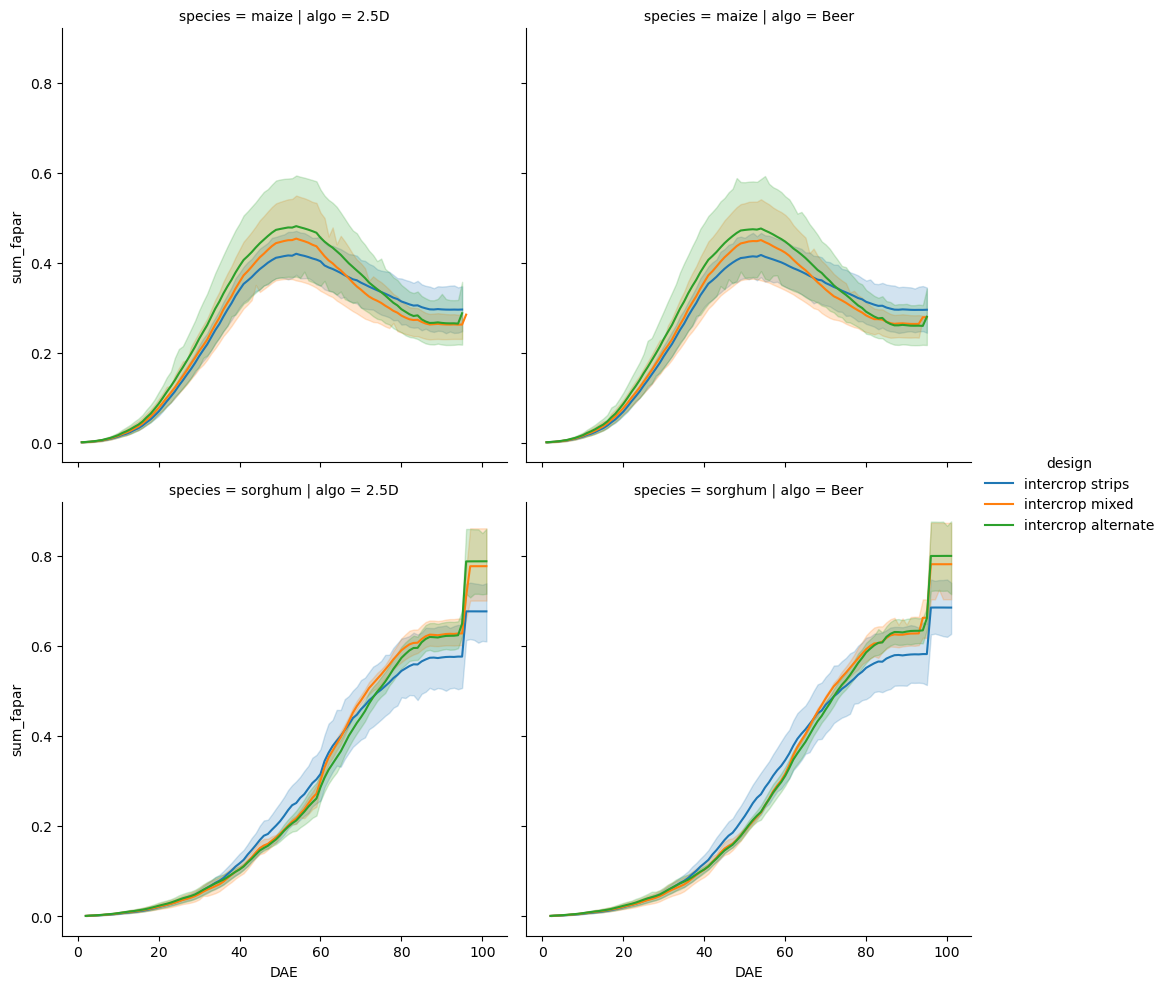

In [33]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="design",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_designs.png')

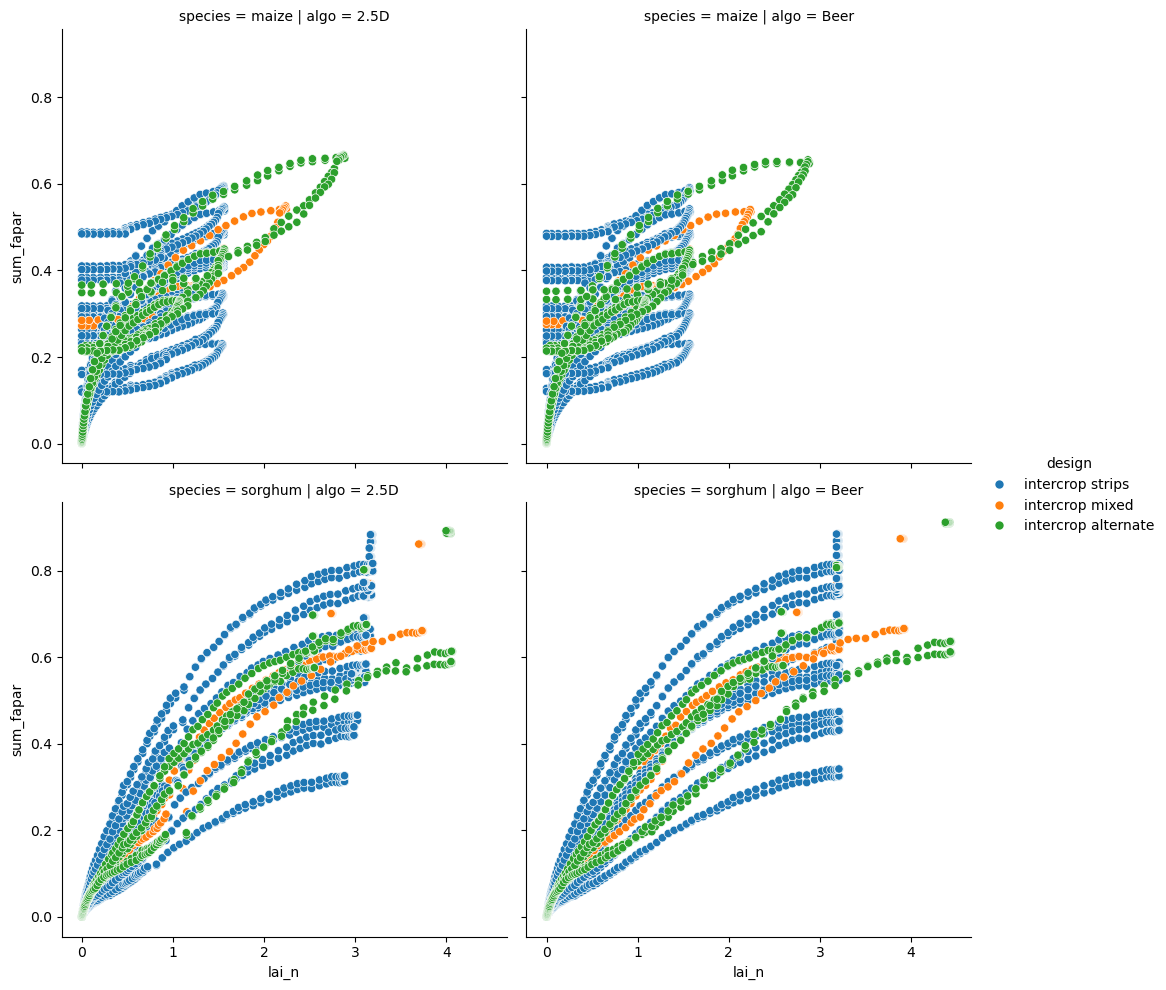

In [153]:
plot = sns.relplot(
    data=simultaneous,
    x="lai_n", 
    y="sum_fapar",
    hue="design",
    row="species",
    col="algo",
    kind="scatter",
)

plot.savefig('../2-outputs/light_designs_LAI.png')

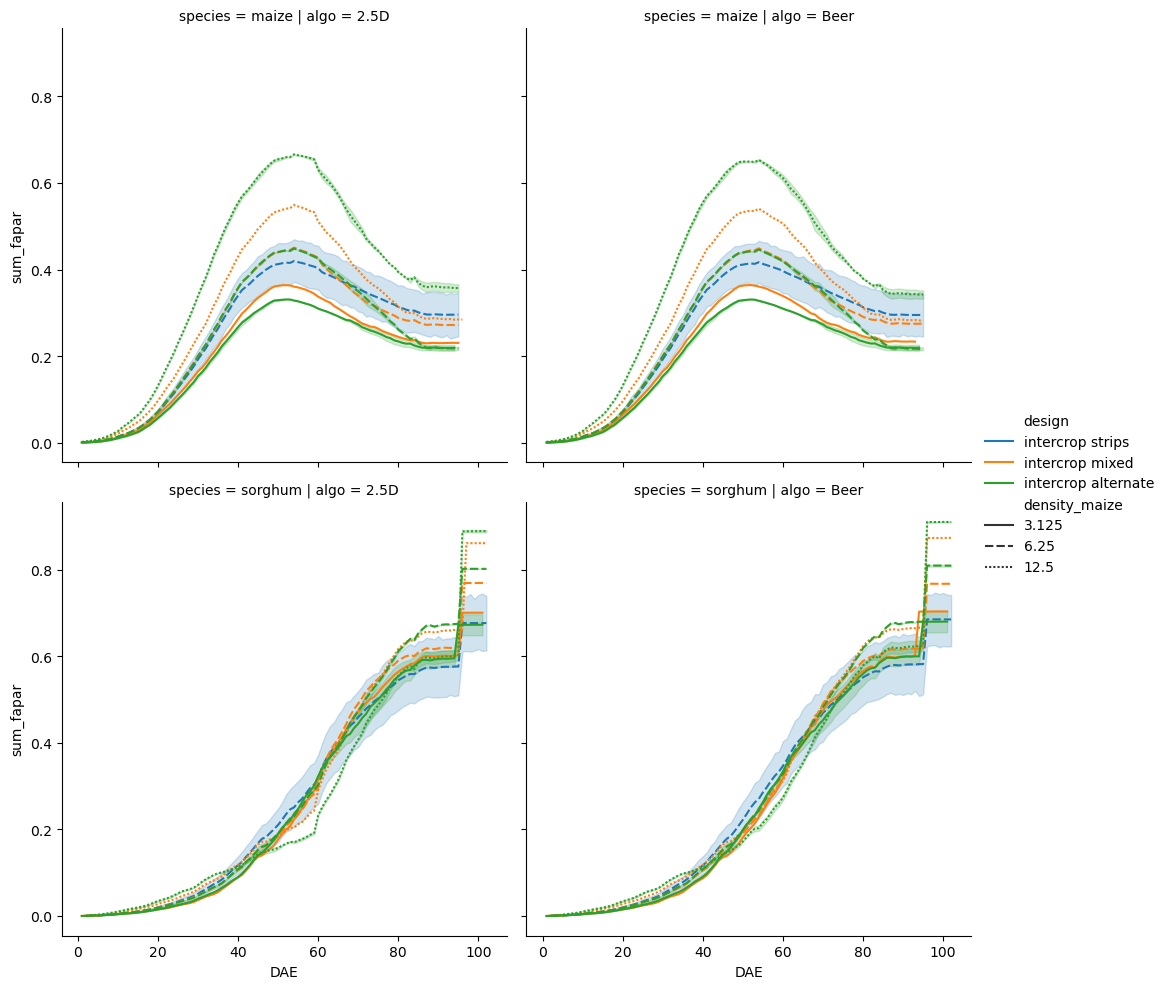

In [13]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="design",
    row="species",
    col="algo",
    style="density_maize",
    kind="line",
)

plot.

plot.savefig('../2-outputs/light_designs_density.png')

In [54]:
alt_low_NS = simultaneous[simultaneous["usm"]=="usm_4"]
alt_low_NS_2D = alt_low_NS[alt_low_NS["algo"]=="2.5D"]
alt_low_NS_2D_maize = alt_low_NS_2D.loc[alt_low_NS_2D["species"]=="maize", "sum_fapar"]
alt_low_NS_2D_sorghum = alt_low_NS_2D.loc[alt_low_NS_2D["species"]=="sorghum", "sum_fapar"]

mix_low_NS = simultaneous[simultaneous["usm"]=="usm_1"]
mix_low_NS_2D = mix_low_NS[mix_low_NS["algo"]=="2.5D"]
mix_low_NS_2D_maize = mix_low_NS_2D.loc[mix_low_NS_2D["species"]=="maize", "sum_fapar"]
mix_low_NS_2D_sorghum = mix_low_NS_2D.loc[mix_low_NS_2D["species"]=="sorghum", "sum_fapar"]

print(f"RMSE alt vs. mix maize low density: {((np.array(alt_low_NS_2D_maize) - np.array(mix_low_NS_2D_maize)[:-1]) ** 2).mean() ** .5:.3f}")
print(f"RMSE alt vs. mix sorghum low density: {((np.array(alt_low_NS_2D_sorghum) - np.array(mix_low_NS_2D_sorghum)) ** 2).mean() ** .5:.3f}")

RMSE alt vs. mix maize low density: 0.015
RMSE alt vs. mix sorghum low density: 0.025


In [56]:
alt_middle_NS = simultaneous[simultaneous["usm"]=="usm_5"]
alt_middle_NS_2D = alt_middle_NS[alt_middle_NS["algo"]=="2.5D"]
alt_middle_NS_2D_maize = alt_middle_NS_2D.loc[alt_middle_NS_2D["species"]=="maize", "sum_fapar"]
alt_middle_NS_2D_sorghum = alt_middle_NS_2D.loc[alt_middle_NS_2D["species"]=="sorghum", "sum_fapar"]

mix_middle_NS = simultaneous[simultaneous["usm"]=="usm_2"]
mix_middle_NS_2D = mix_middle_NS[mix_middle_NS["algo"]=="2.5D"]
mix_middle_NS_2D_maize = mix_middle_NS_2D.loc[mix_middle_NS_2D["species"]=="maize", "sum_fapar"]
mix_middle_NS_2D_sorghum = mix_middle_NS_2D.loc[mix_middle_NS_2D["species"]=="sorghum", "sum_fapar"]

print(f"RMSE alt vs. mix maize middle density: {((np.array(alt_middle_NS_2D_maize) - np.array(mix_middle_NS_2D_maize)) ** 2).mean() ** .5:.3f}")
print(f"RMSE alt vs. mix sorghum middle density: {((np.array(alt_middle_NS_2D_sorghum) - np.array(mix_middle_NS_2D_sorghum)) ** 2).mean() ** .5:.3f}")

RMSE alt vs. mix maize middle density: 0.020
RMSE alt vs. mix sorghum middle density: 0.022


In [58]:
alt_high_NS = simultaneous[simultaneous["usm"]=="usm_6"]
alt_high_NS_2D = alt_high_NS[alt_high_NS["algo"]=="2.5D"]
alt_high_NS_2D_maize = alt_high_NS_2D.loc[alt_high_NS_2D["species"]=="maize", "sum_fapar"]
alt_high_NS_2D_sorghum = alt_high_NS_2D.loc[alt_high_NS_2D["species"]=="sorghum", "sum_fapar"]

mix_high_NS = simultaneous[simultaneous["usm"]=="usm_3"]
mix_high_NS_2D = mix_high_NS[mix_high_NS["algo"]=="2.5D"]
mix_high_NS_2D_maize = mix_high_NS_2D.loc[mix_high_NS_2D["species"]=="maize", "sum_fapar"]
mix_high_NS_2D_sorghum = mix_high_NS_2D.loc[mix_high_NS_2D["species"]=="sorghum", "sum_fapar"]

print(f"RMSE alt vs. mix maize high density: {((np.array(alt_high_NS_2D_maize) - np.array(mix_high_NS_2D_maize)[:-1]) ** 2).mean() ** .5:.3f}")
print(f"RMSE alt vs. mix sorghum high density: {((np.array(alt_high_NS_2D_sorghum) - np.array(mix_high_NS_2D_sorghum)) ** 2).mean() ** .5:.3f}")

RMSE alt vs. mix maize high density: 0.089
RMSE alt vs. mix sorghum high density: 0.043


In [14]:
simultaneous

,step_number,sum_fapar,usm,algo,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,...,interrow_maize,intrarow,n_rows_sorghum,n_rows_maize,density_sorghum,density_maize,width,length,domain_area,fapar_crop
0,1,0.000977,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.000509
1,2,0.001464,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.000763
2,3,0.002019,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.001052
3,4,0.002865,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.001492
4,5,0.003933,usm_10,2.5D,intercrop strips,N-S,middle,middle,high,high,...,0.4,0.4,6,6,6.25,6.25,4.8,0.4,1.92,0.002048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18170,98,0.911272,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.695449
18171,99,0.911317,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.695729
18172,100,0.911588,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.697423
18173,101,0.911455,usm_9,Beer,intercrop alternate,E-W,low,low,one,one,...,0.2,0.4,1,1,12.50,12.50,0.4,0.4,0.16,5.696592


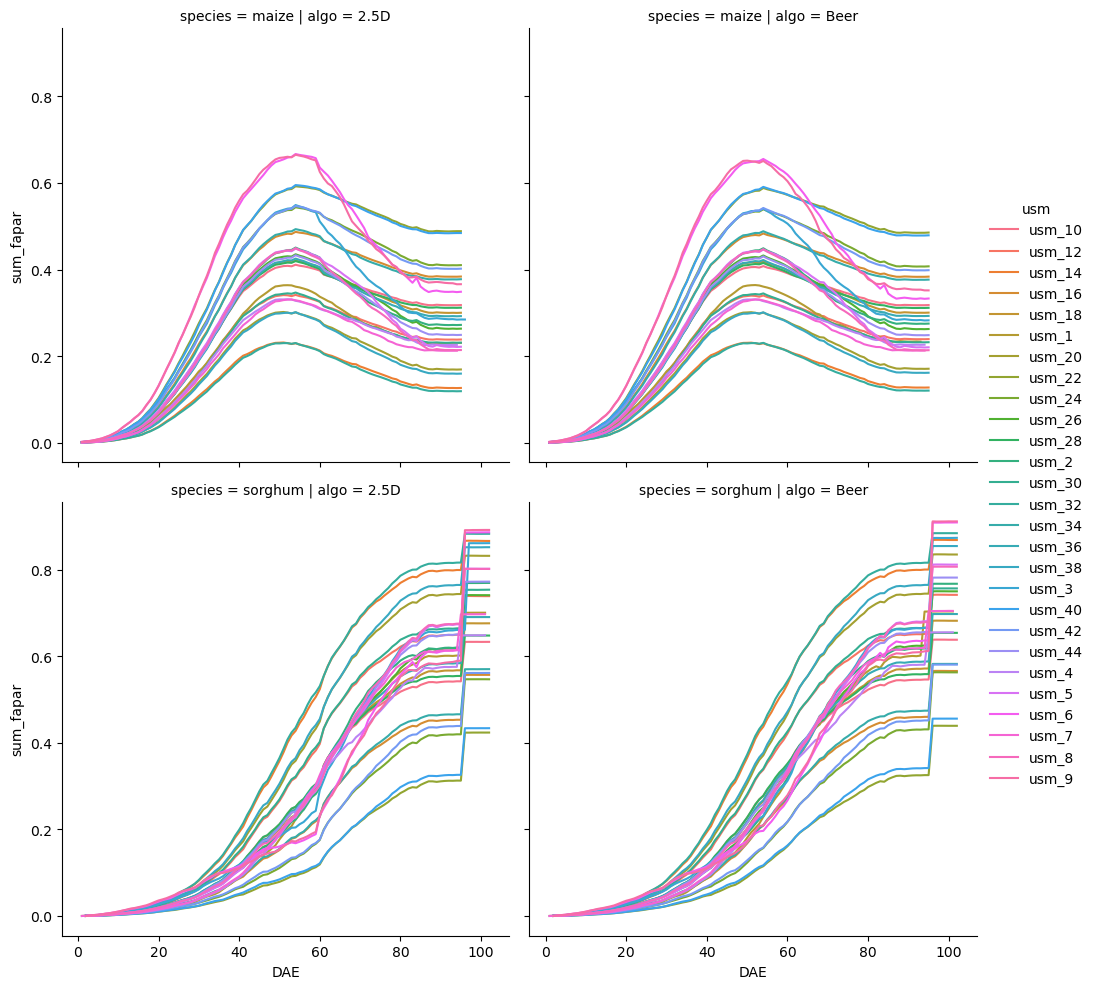

In [15]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="usm",
    row="species",
    col="algo",
    kind="line",
)

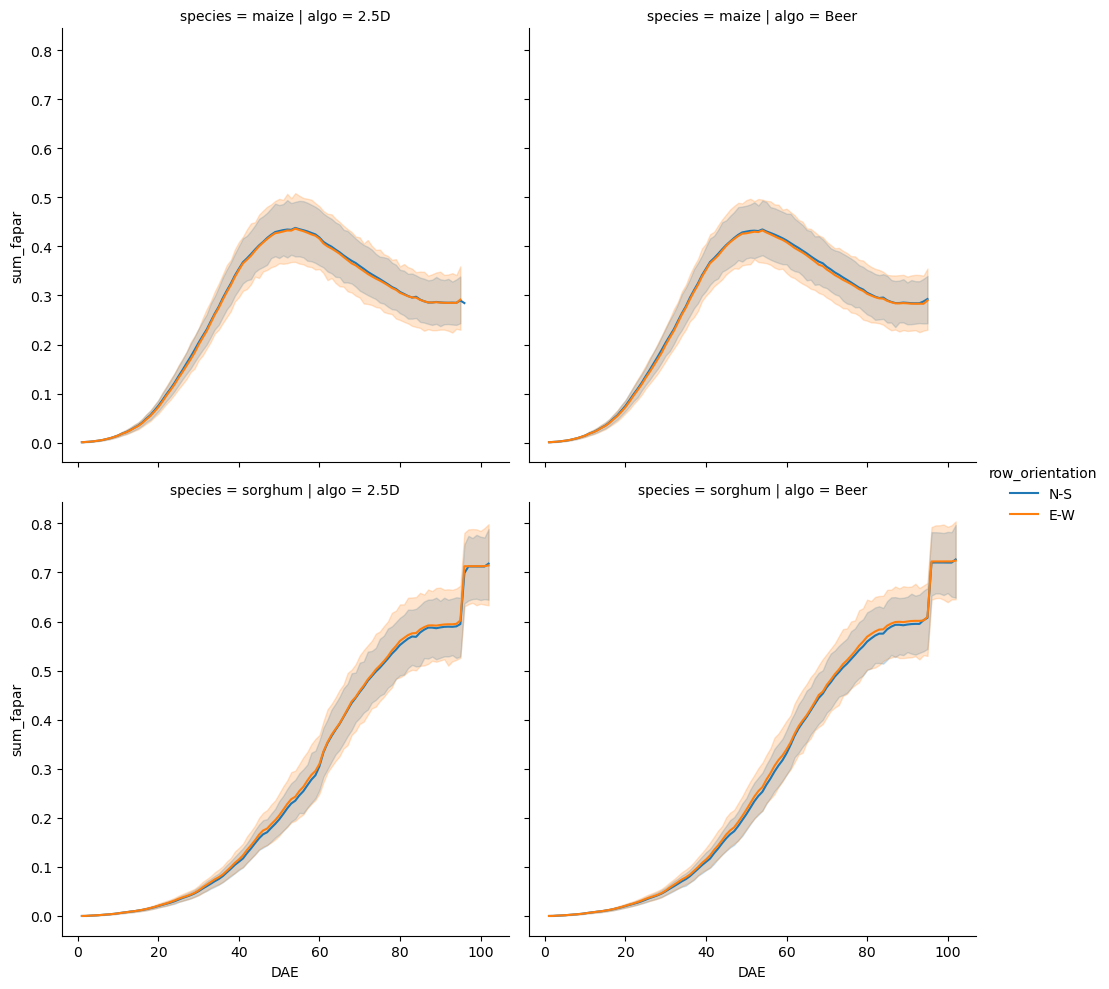

In [16]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="row_orientation",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_orientation.png')

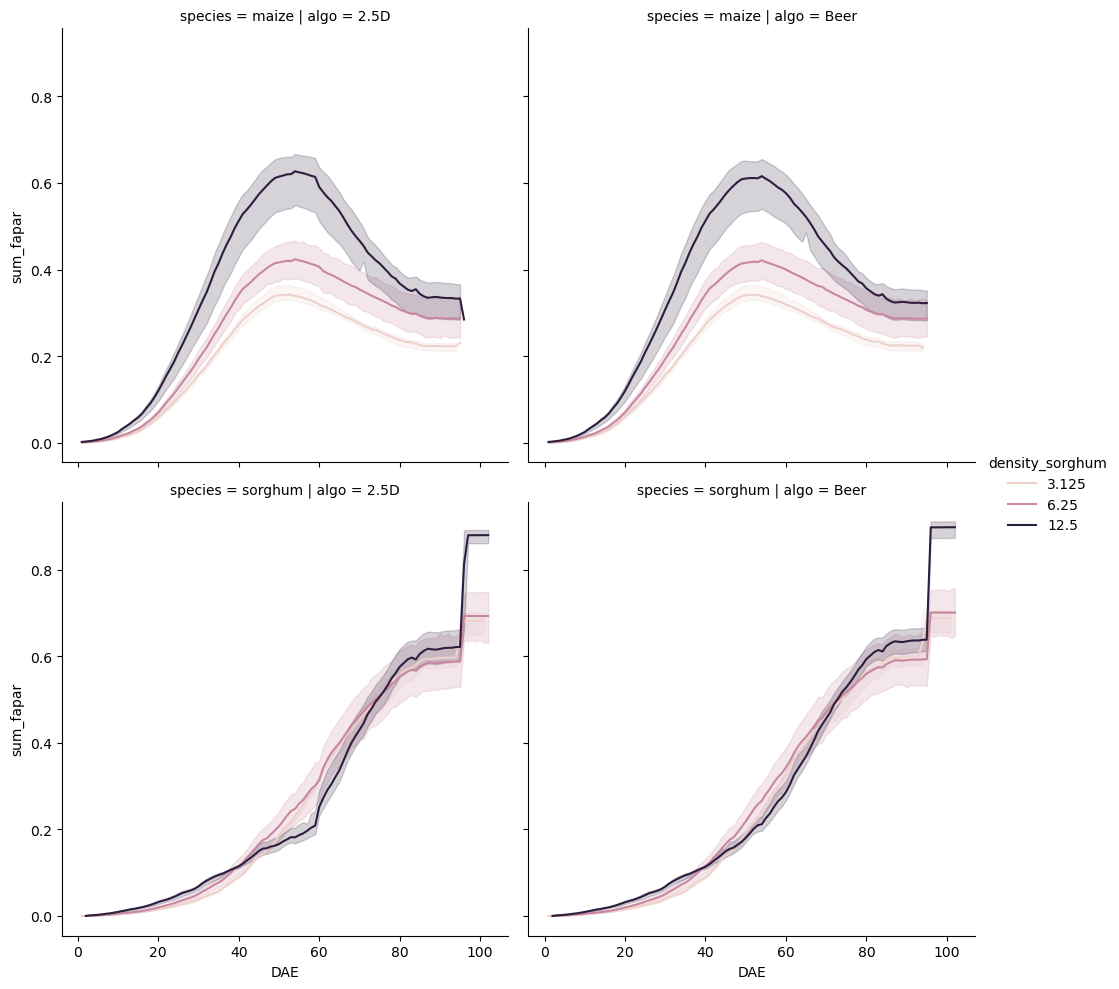

In [17]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="sum_fapar",
    hue="density_sorghum",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_density.png')

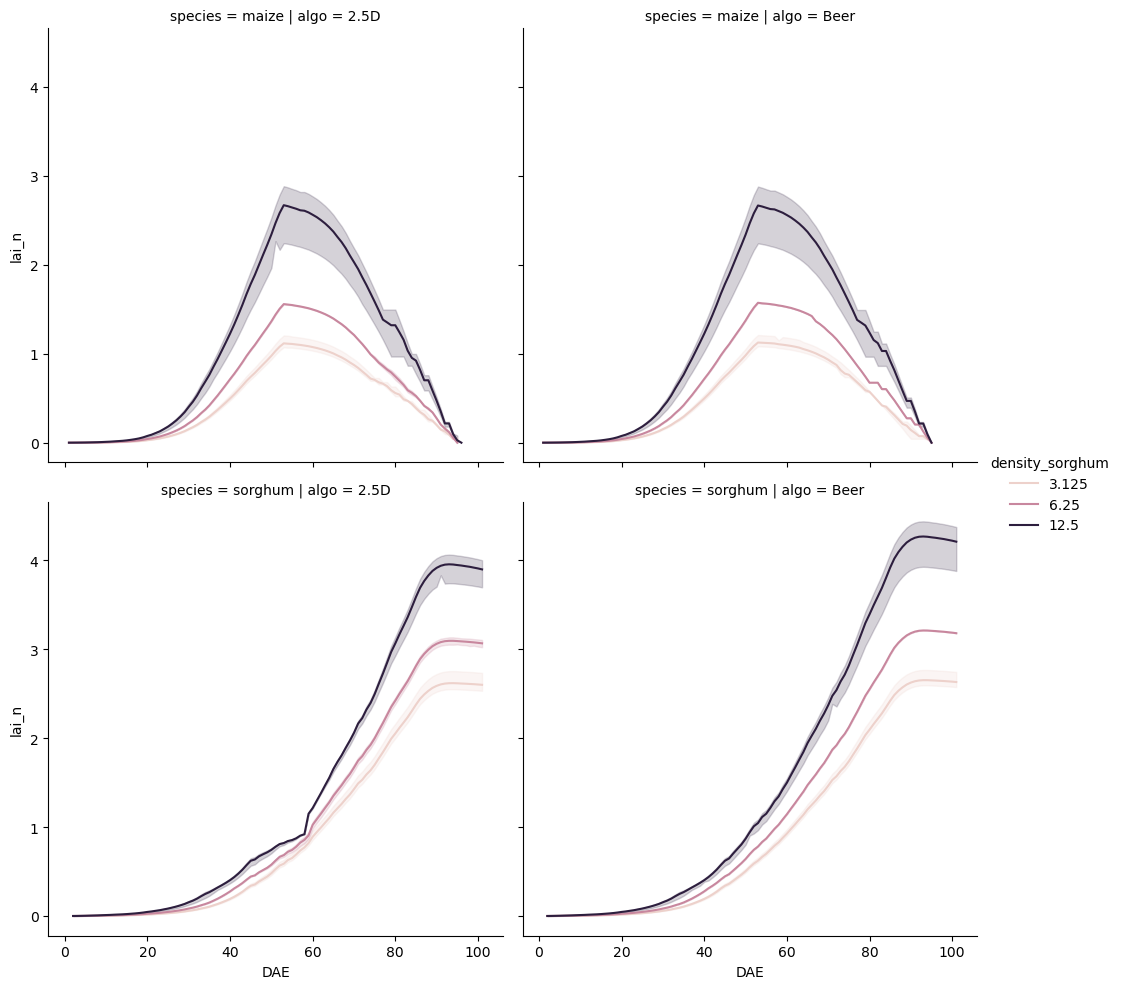

In [35]:
plot = sns.relplot(
    data=simultaneous,
    x="DAE", 
    y="lai_n",
    hue="density_sorghum",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/LAI.png')

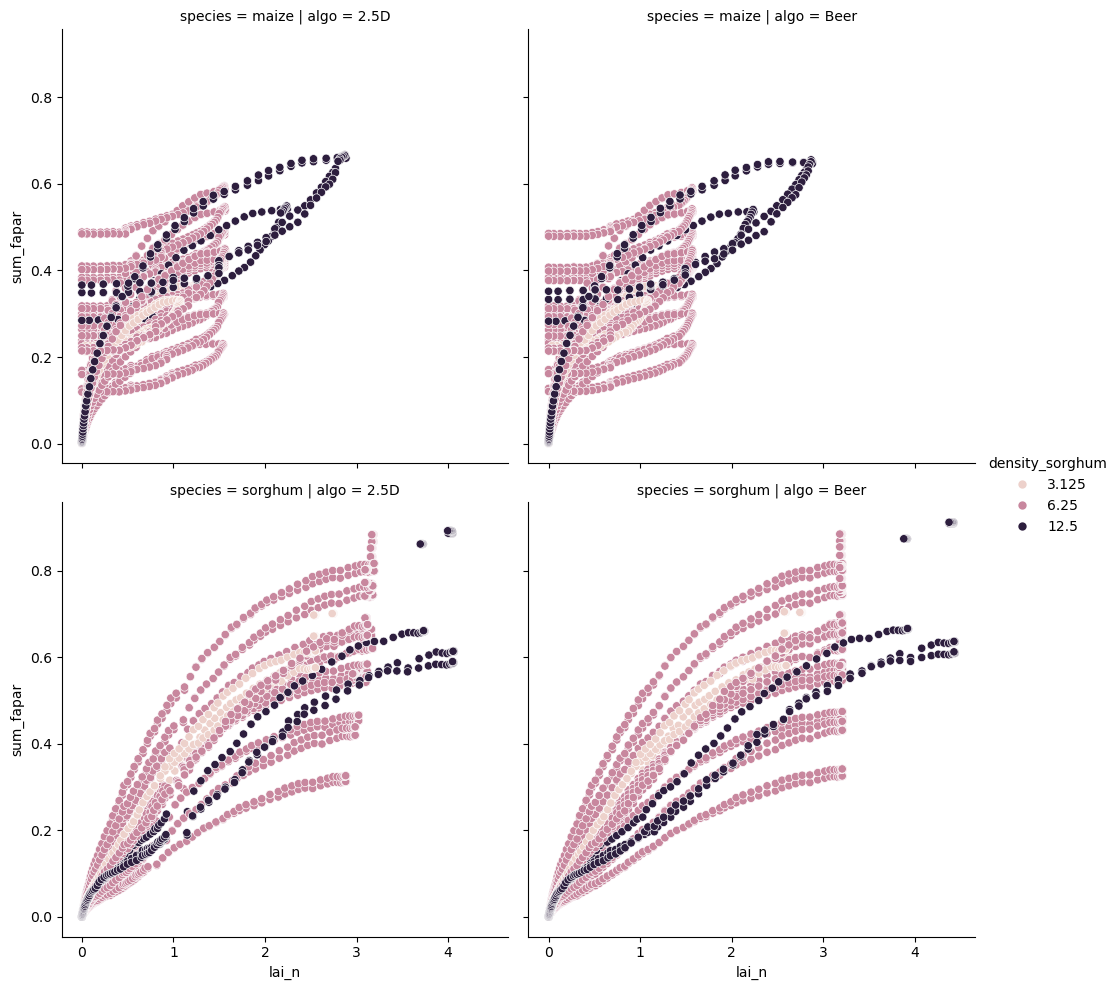

In [154]:
plot = sns.relplot(
    data=simultaneous,
    x="lai_n", 
    y="sum_fapar",
    hue="density_sorghum",
    row="species",
    col="algo",
    kind="scatter",
)

plot.savefig('../2-outputs/light_density_LAI.png')

In [14]:
strips = merged[merged["design"] == "intercrop strips"]

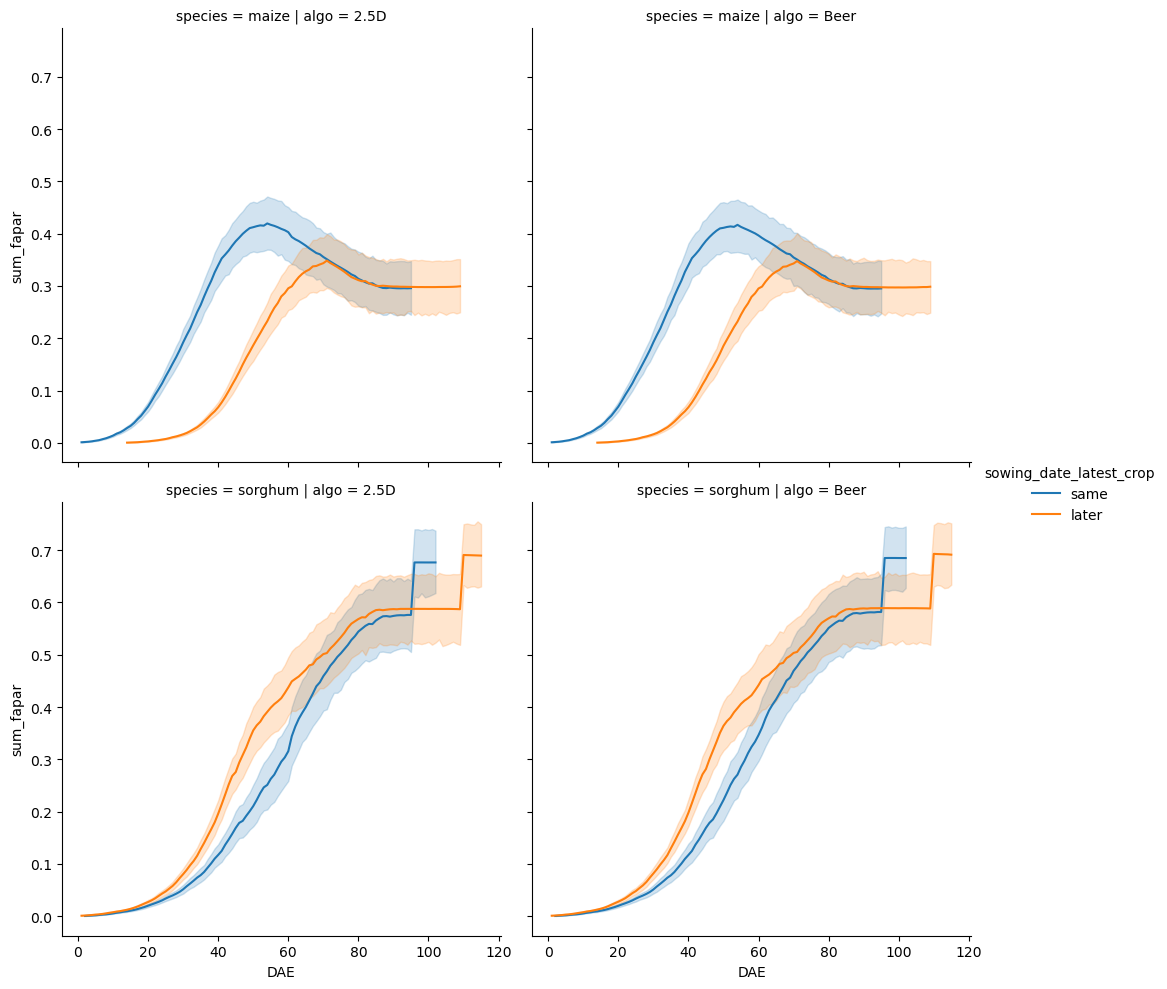

In [20]:
plot = sns.relplot(
    data=strips,
    x="DAE", 
    y="sum_fapar",
    hue="sowing_date_latest_crop",
    row="species",
    col="algo",
    kind="line",
)

plot.savefig('../2-outputs/light_sowing_date.png')

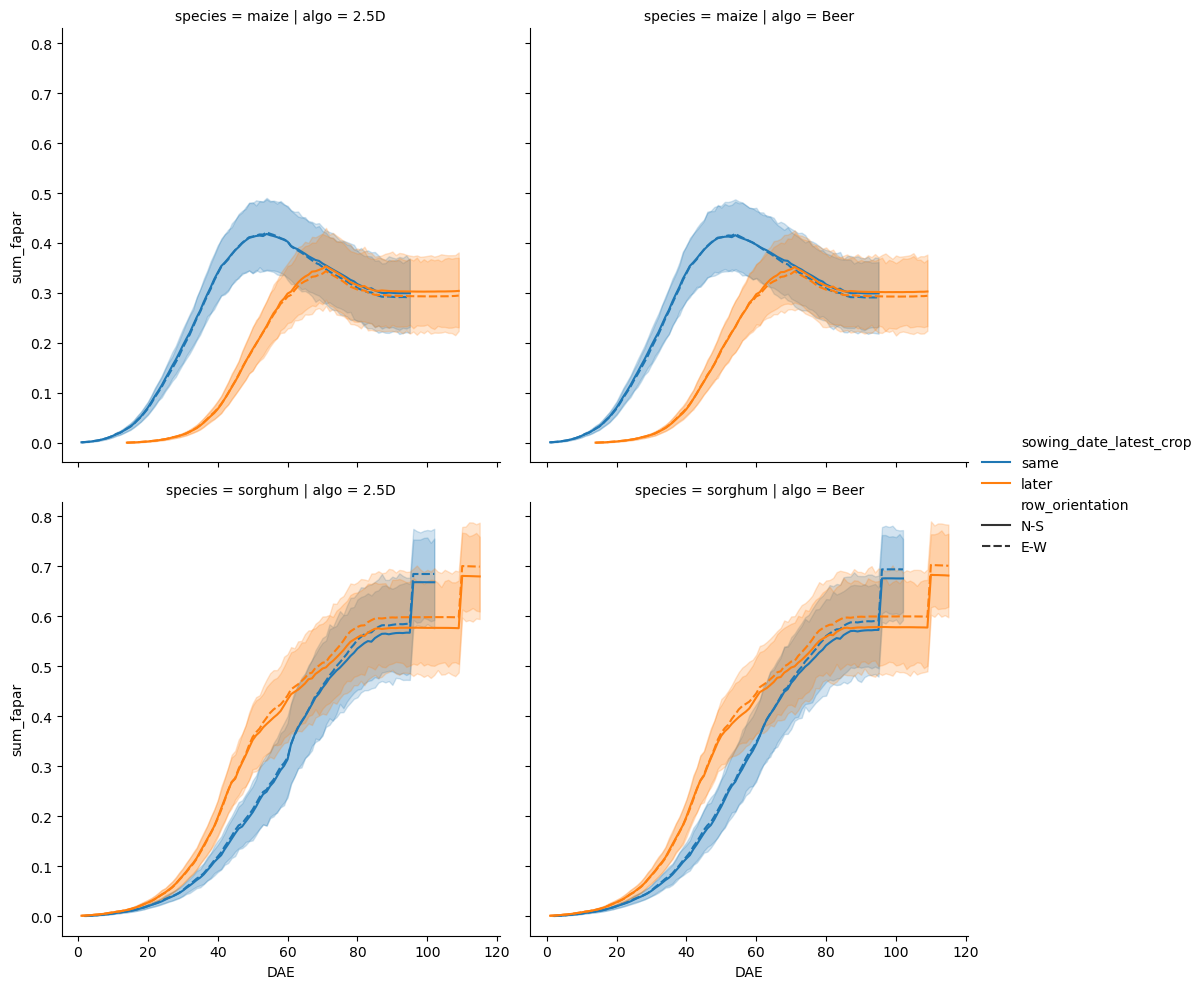

In [21]:
plot = sns.relplot(
    data=strips,
    x="DAE", 
    y="sum_fapar",
    hue="sowing_date_latest_crop",
    style="row_orientation",
    row="species",
    col="algo",
    kind="line",
)

In [75]:
from sklearn.linear_model import LinearRegression

df = simultaneous.copy()
df["cum_aPAR_3D"] = np.nan
df["cum_aPAR_stics"] = np.nan
df["regression"] = np.nan
df["reference"] = np.nan
df["abs_difference"] = np.nan

for _, group in df.groupby(group_cols):

    # Sort if the cumulative sum depends on an ordering variable
    group = group.sort_values("cum_aPAR_3D")  

    # Cumulative sums
    x_cum = group["cum_aPAR_3D"].cumsum()
    y_cum = group["cum_aPAR_stics"].cumsum()

    # Final cumulative values
    x_last = x_cum.iloc[-1]
    y_last = y_cum.iloc[-1]

    # Straight line from (0, 0) to (x_last, y_last)
    slope = y_last / x_last

    # Reference y for every cumulative x
    y_reference = slope * x_cum

    # Store results
    df.loc[group.index, "cum_aPAR_3D"] = x_cum
    df.loc[group.index, "cum_aPAR_stics"] = y_cum
    df.loc[group.index, "reference"] = y_reference
    df.loc[group.index, "abs_difference"] = (y_last - y_reference).abs()

# # Fit one regression per curve
# for (algo, species, usm), group in df.groupby(["algo", "species", "usm"]):
#     X = group[["sum_fapar"]]
#     y = group["fapar_stics"]

#     model = LinearRegression().fit(X, y)
#     df.loc[group.index, "regression"] = model.predict(X)

# # Absolute difference / residual
# df["SEu"] = (df["fapar_stics"] - df["regression"]) ** 2
# df["SEs"] = (df["sum_fapar"] - df["regression"]) ** 2

# rrmse = {}
# for u in [f"usm_{i}" for i in range(1,46)]:
#     rrmse[u] = {}
#     for a in ["2.5D", "Beer"]:
#         rrmse[u][a] = {}
#         for s in ["maize", "sorghum"]:
#             df_tmp = df[(df["usm"]==u) & (df["algo"]==a) & (df["species"]==s)]
#             RMSEu = np.array(df_tmp["SEu"]).mean() ** .5 
#             rRMSEu = (RMSEu / np.array(df_tmp["sum_fapar"]).std())
#             RMSEs = np.array(df_tmp["SEs"]).mean() ** .5 
#             rRMSEs = (RMSEs / np.array(df_tmp["sum_fapar"]).std())
#             rrmse[u][a][s] = {"rRMSEu":round(rRMSEu,3), "rRMSEs":round(rRMSEs,3)}

C:\Users\cheriere\AppData\Local\Temp\ipykernel_31584\3705710799.py:27: RuntimeWarning: Mean of empty slice.
  RMSEu = np.array(df_tmp["SEu"]).mean() ** .5
c:\Users\cheriere\miniconda3\envs\caribu\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\cheriere\miniconda3\envs\caribu\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\cheriere\miniconda3\envs\caribu\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\cheriere\miniconda3\envs\caribu\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\cheriere\AppData\Local\Temp\ipykernel_31584\3705710799.py:29: RuntimeWarning

In [177]:
rows = []

for u, usms in rrmse.items():
    for a, algos in usms.items():
        for s, r in algos.items():
                rows.append({
                    "usm": u,
                    "algo": a,
                    "species": s,
                    "rRMSEu": r["rRMSEu"],
                    "rRMSEs": r["rRMSEs"],
                    "rRMSEu_avg": np.array([sp["rRMSEu"] for sp in algos.values()]).mean(),
                    "rRMSEs_avg": np.array([sp["rRMSEs"] for sp in algos.values()]).mean(),
                    # **values,
                })

df_rrmse = pd.DataFrame(rows)
df_rrmse = pd.merge(df_rrmse, df_doe, on=["usm"])
df_rrmse = pd.merge(df_rrmse, merged[["usm","proportion_sorghum","density_sorghum"]], on=["usm"])
df_rrmse

,usm,algo,species,rRMSEu,rRMSEs,rRMSEu_avg,rRMSEs_avg,species_id,species_principal,species_secondary,design,row_orientation,interrow_distance_principal,interrow_distance_secondary,n_rows_principal,n_rows_secondary,intrarow_distance,sowing_date_latest_crop,proportion_sorghum,density_sorghum
0,usm_1,2.5D,maize,0.49,0.66,0.309,0.371,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,high,same,50.0,3.125
1,usm_1,2.5D,maize,0.49,0.66,0.309,0.371,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,high,same,50.0,3.125
2,usm_1,2.5D,maize,0.49,0.66,0.309,0.371,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,high,same,50.0,3.125
3,usm_1,2.5D,maize,0.49,0.66,0.309,0.371,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,high,same,50.0,3.125
4,usm_1,2.5D,maize,0.49,0.66,0.309,0.371,sorghum-maize_trop,sorghum,maize_trop,intercrop mixed,N-S,middle,middle,one,one,high,same,50.0,3.125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71999,usm_45,Beer,sorghum,NaN,NaN,NaN,NaN,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,E-W,middle,middle,low,low,middle,later,50.0,6.250
72000,usm_45,Beer,sorghum,NaN,NaN,NaN,NaN,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,E-W,middle,middle,low,low,middle,later,50.0,6.250
72001,usm_45,Beer,sorghum,NaN,NaN,NaN,NaN,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,E-W,middle,middle,low,low,middle,later,50.0,6.250
72002,usm_45,Beer,sorghum,NaN,NaN,NaN,NaN,sorghum-maize_trop,sorghum,maize_trop,intercrop strips,E-W,middle,middle,low,low,middle,later,50.0,6.250


In [180]:
from matplotlib.patches import Wedge

def arrange_sns_plot(plot, xlim=1.6, ylim=1.6):
    for ax in plot.axes.flat:
        ax.axline((0, 0), slope=1, color="grey", linestyle="--")
        ax.set_xlim([0,xlim])
        ax.set_ylim([0,ylim])
        
        wedge = Wedge(
            center=(0, 0),
            r=0.5,
            theta1=0,
            theta2=90,
            alpha=0.2,
            color="grey"
        )
        ax.add_patch(wedge)
    
        wedge = Wedge(
            center=(0, 0),
            r=0.6,
            theta1=0,
            theta2=90,
            alpha=0.2,
            color="grey"
        )
        ax.add_patch(wedge)
    
        wedge = Wedge(
            center=(0, 0),
            r=0.7,
            theta1=0,
            theta2=90,
            alpha=0.2,
            color="grey"
        )
        ax.add_patch(wedge)

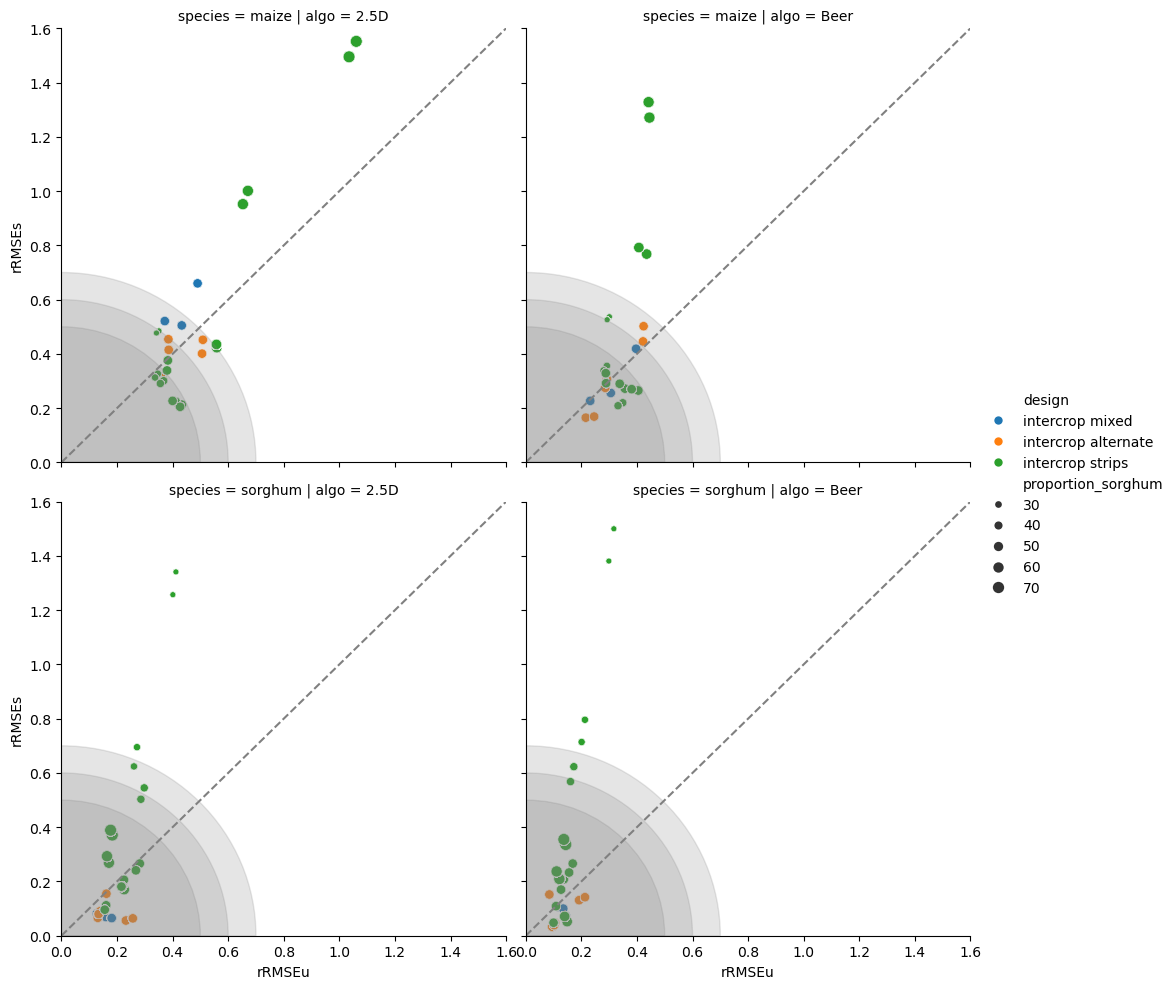

In [174]:
plot = sns.relplot(
    data=df_rrmse,
    x="rRMSEu", 
    y="rRMSEs",
    hue="design",
    row="species",
    col="algo",
    kind="scatter",
    size="proportion_sorghum",
)

arrange_sns_plot(plot)

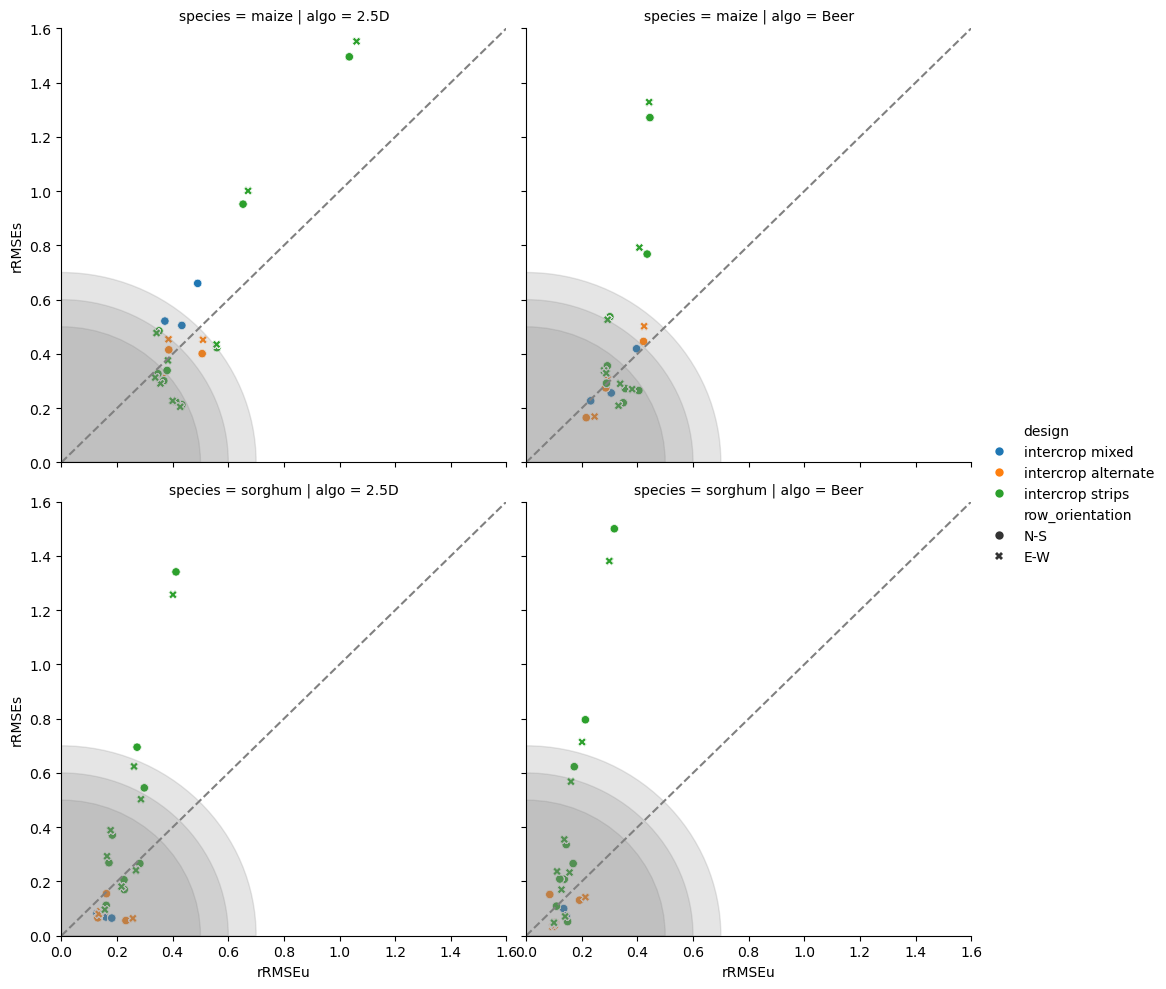

In [151]:
plot = sns.relplot(
    data=df_rrmse,
    x="rRMSEu", 
    y="rRMSEs",
    hue="design",
    row="species",
    col="algo",
    kind="scatter",
    style="row_orientation",
)

arrange_sns_plot(plot)

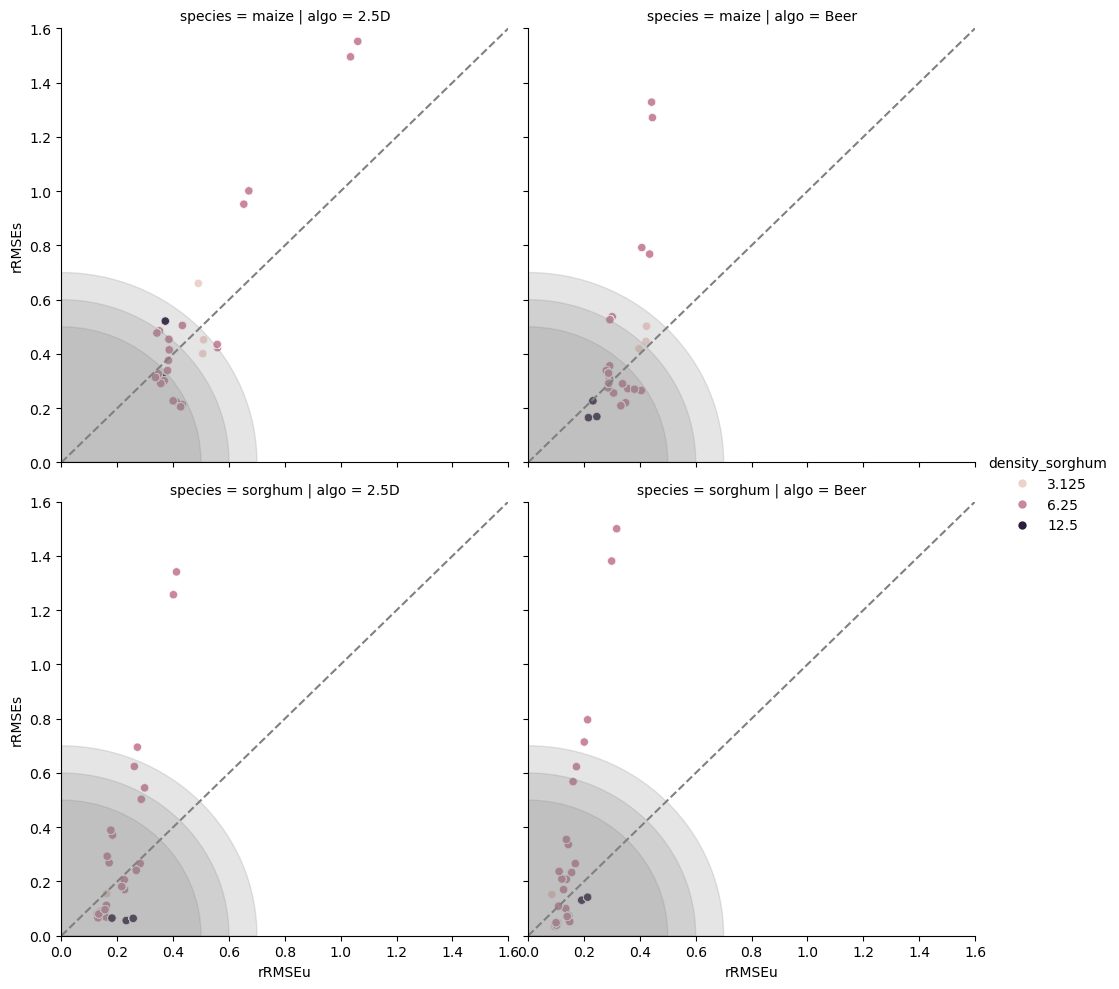

In [152]:
plot = sns.relplot(
    data=df_rrmse,
    x="rRMSEu", 
    y="rRMSEs",
    hue="density_sorghum",
    row="species",
    col="algo",
    kind="scatter",
)

arrange_sns_plot(plot)

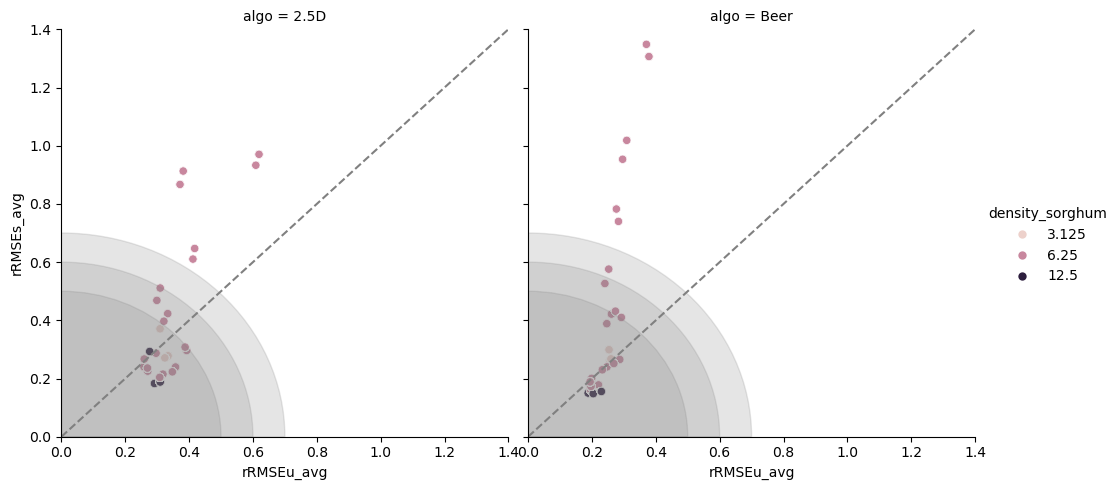

In [181]:
plot = sns.relplot(
    data=df_rrmse,
    x="rRMSEu_avg", 
    y="rRMSEs_avg",
    hue="density_sorghum",
    col="algo",
    kind="scatter",
)

arrange_sns_plot(plot, 1.4, 1.4)

In [ ]:
plot = sns.relplot(
    data=df_rrmse,
    x="rRMSEu_avg", 
    y="rRMSEs_avg",
    hue="design",
    col="algo",
    kind="scatter",
    size="proportion_sorghum",
)

arrange_sns_plot(plot)

def label_point(x, y, val, plot):
    for ax in plot.axes.flat:
        a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
        for i, point in a.iterrows():
            if x >= 0.8 or y >= 0.8:
                ax.text(point['x']+.02, point['y'], str(point['val']))

label_point(df_rrmse.rRMSEu_avg, df_rrmse.rRMSEs_avg, df_rrmse.usm, plot) 

In [ ]:
df

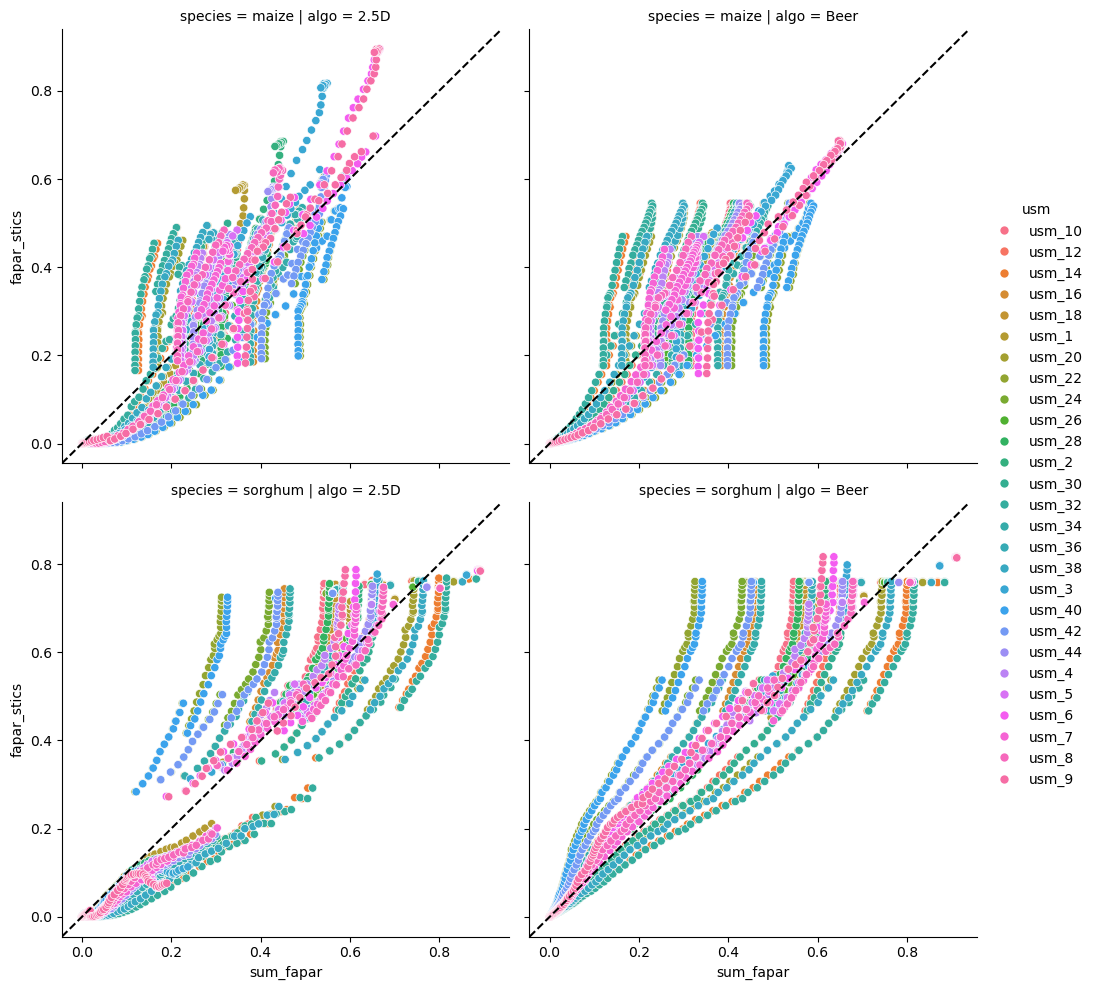

In [141]:
plot = sns.relplot(
    data=simultaneous,
    x="sum_fapar", 
    y="fapar_stics",
    hue="usm",
    row="species",
    col="algo",
    kind="scatter",
)

for ax in plot.axes.flat:
    ax.axline((0, 0), slope=1, color="k", linestyle="--")

# for i, row_value in enumerate(plot.row_names):
#     for j, col_value in enumerate(plot.col_names):

#         ax = plot.axes[i, j]

#         facet_df = df[
#             (df["species"] == row_value) &
#             (df["algo"] == col_value)
#         ]

#         for curve, curve_df in facet_df.groupby("usm"):
#             curve_df = curve_df.sort_values("sum_fapar")

#             ax.plot(
#                 curve_df["sum_fapar"],
#                 curve_df["regression"],
#                 "--",
#                 alpha=0.8,
#                 color="grey"
#             )

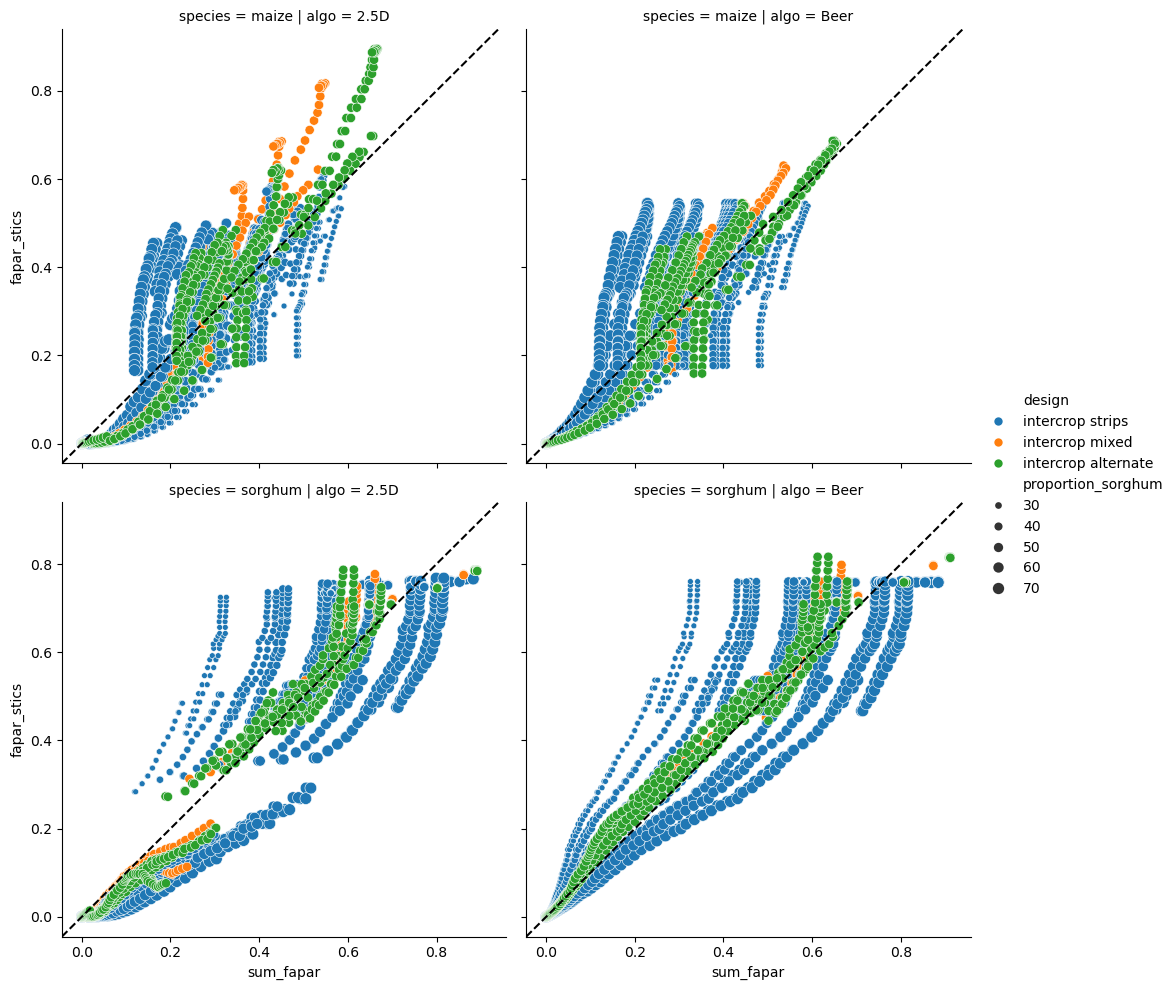

In [175]:
plot = sns.relplot(
    data=simultaneous,
    x="sum_fapar", 
    y="fapar_stics",
    hue="design",
    row="species",
    col="algo",
    size="proportion_sorghum",
    kind="scatter",
)

for ax in plot.axes.flat:
    ax.axline((0, 0), slope=1, color="k", linestyle="--")